# EDA

In [3]:
import pandas as pd

data = pd.read_csv("../data/mental_health_burnout_prediction_dataset.csv")

data.head()

,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person_ID                      50000 non-null  int64  
 1   Age                            49750 non-null  float64
 2   Gender                         50000 non-null  str    
 3   Country                        50000 non-null  str    
 4   Occupation                     50000 non-null  str    
 5   Education_Level                50000 non-null  str    
 6   Employment_Status              50000 non-null  str    
 7   Monthly_Income_USD             48550 non-null  float64
 8   Work_Hours_Per_Week            50000 non-null  int64  
 9   Remote_Work                    50000 non-null  str    
 10  Job_Satisfaction               49500 non-null  float64
 11  Work_Life_Balance              49350 non-null  float64
 12  Sleep_Hours                    49050 non-null  float64
 1

In [5]:
columns = [
    "Mental_Health_Status",
    "Stress_Level",
    "Chronic_Stress",
    "Work_Hours_Per_Week",
    "Screen_Time_Hours",
    "Meditation_Minutes",
    "Sleep_Hours",
    "Sleep_Quality",
    "Physical_Activity_Hours",
    "Burnout_Score"
]

data = data[columns]

data.head()

,Mental_Health_Status,Stress_Level,Chronic_Stress,Work_Hours_Per_Week,Screen_Time_Hours,Meditation_Minutes,Sleep_Hours,Sleep_Quality,Physical_Activity_Hours,Burnout_Score
0,Critical,High,Yes,67,9.1,5.0,4.6,Poor,8.9,82
1,Critical,Moderate,No,44,12.0,18.0,4.7,Poor,0.8,64
2,Needs Attention,Moderate,No,60,10.2,NaN,6.3,Average,6.9,50
3,Healthy,Low,No,25,3.3,55.0,7.1,Good,7.6,16
4,Healthy,Low,No,52,6.5,9.0,9.1,Excellent,6.1,26


In [6]:
data = data.dropna()

data.info()

<class 'pandas.DataFrame'>
Index: 46032 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Mental_Health_Status     46032 non-null  str    
 1   Stress_Level             46032 non-null  str    
 2   Chronic_Stress           46032 non-null  str    
 3   Work_Hours_Per_Week      46032 non-null  int64  
 4   Screen_Time_Hours        46032 non-null  float64
 5   Meditation_Minutes       46032 non-null  float64
 6   Sleep_Hours              46032 non-null  float64
 7   Sleep_Quality            46032 non-null  str    
 8   Physical_Activity_Hours  46032 non-null  float64
 9   Burnout_Score            46032 non-null  int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 4.9 MB


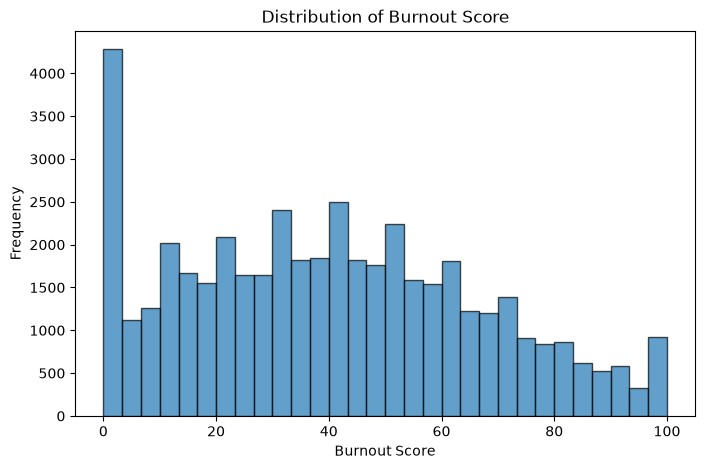

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data["Burnout_Score"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Burnout Score")
plt.ylabel("Frequency")
plt.title("Distribution of Burnout Score")
plt.show()

In [8]:
print(data["Stress_Level"].unique().tolist())
print(data["Mental_Health_Status"].unique().tolist())
print(data["Chronic_Stress"].unique().tolist())
print(data["Sleep_Quality"].unique().tolist())

['High', 'Moderate', 'Low']
['Critical', 'Healthy', 'Needs Attention']
['Yes', 'No']
['Poor', 'Good', 'Excellent', 'Average']


In [9]:
# Mental_Health_Status Stress_Level Chronic_Stress Sleep_Quality

from sklearn.preprocessing import OrdinalEncoder

stress_lvl_encoder = OrdinalEncoder(categories=[["High", "Moderate", "Low"]])

mental_health_status_encoder = OrdinalEncoder(categories=[["Critical", "Needs Attention", "Healthy"]])

sleep_quality_encoder = OrdinalEncoder(categories=[["Poor", "Average", "Good", "Excellent"]])

data["Stress_Level"] = stress_lvl_encoder.fit_transform(data[["Stress_Level"]])

data["Mental_Health_Status"] = mental_health_status_encoder.fit_transform(data[["Mental_Health_Status"]])

data["Sleep_Quality"] = sleep_quality_encoder.fit_transform(data[["Sleep_Quality"]])

data = pd.get_dummies(data, columns=["Chronic_Stress"])

data.head()

,Mental_Health_Status,Stress_Level,Work_Hours_Per_Week,Screen_Time_Hours,Meditation_Minutes,Sleep_Hours,Sleep_Quality,Physical_Activity_Hours,Burnout_Score,Chronic_Stress_No,Chronic_Stress_Yes
0,0.0,0.0,67,9.1,5.0,4.6,0.0,8.9,82,False,True
1,0.0,1.0,44,12.0,18.0,4.7,0.0,0.8,64,True,False
3,2.0,2.0,25,3.3,55.0,7.1,2.0,7.6,16,True,False
4,2.0,2.0,52,6.5,9.0,9.1,3.0,6.1,26,True,False
5,0.0,1.0,64,6.8,19.0,8.5,2.0,2.0,68,True,False


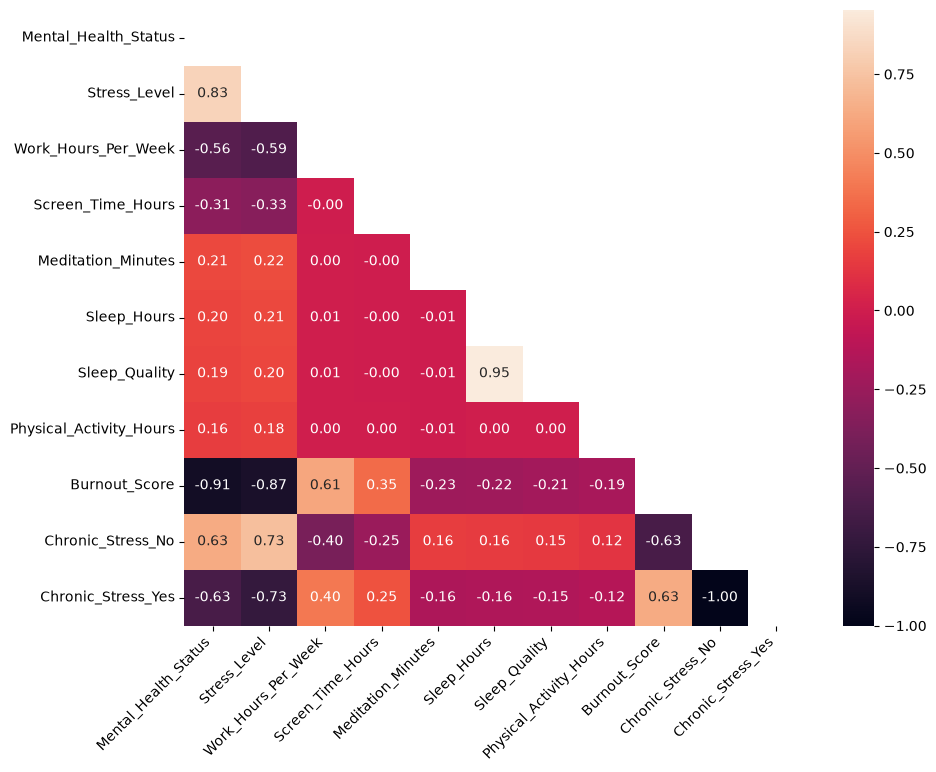

In [10]:
import seaborn as sns
import numpy as np

correlation = data.corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, fmt=".2f", mask=mask)
plt.xticks(rotation=45, ha="right")
plt.show()